## Model validation procedures for:
## Geospatial clustering and temporal contagion of sexual violence in the Colombian armed conflict: 1964 - 2024

In [37]:
# Core Data Manipulation and Utilities ----------------------------------------
library(dplyr)             # Data manipulation
library(janitor)           # Data cleaning utilities

# File I/O and Data Import/Export ---------------------------------------------- 
library(readxl)            # Read Excel files

# Visualisation and Reporting --------------------------------------------------
library(ggplot2)           # Advanced plotting (part of tidyverse but explicit)
library(patchwork)         # Combine multiple plots

# Geospatial Analysis ----------------------------------------------------------
# Basic spatial data handling
library(sf)                # Spatial data manipulation and analysis
library(rnaturalearth)     # Natural Earth map data
library(rnaturalearthdata) # Natural Earth map datasets

# Spatial Point Process Analysis
library(spatstat.geom)     # Spatial point pattern geometry
library(spatstat.linnet)   # Network-based spatial analysis
library(spatstat.explore)  # Pair correlation and Kest

library(terra)             # Spatial data analysis

# Hawkes Process Modelling and Log-Gaussian Cox Process (LGCP) Modelling
library(stelfi)            # Hawkes and log-Gaussian Cox process models

# Additional Log-Gaussian Cox Process (LGCP) Modelling
library(inlabru)           # LGCP model fitting and comparison
library(INLA)              # Integrated nested Laplace approximations
# Note: Install INLA with:
# install.packages("INLA", repos=c(getOption("repos"), 
#                  INLA="https://inla.r-inla-download.org/R/stable"), dep=TRUE)

library(future.apply)      # For parallel lapply (future_lapply)

In [2]:
# Set random seed for reproducibility
set.seed(7550822)

In [3]:
# Path to data files and output directory
data_path <- "/home/main/data/ColSVData/"
output_dir <- "/home/main/data/ColSVOutput/"

### Import conflict event data files

In [4]:

# Define the list of required columns
required_columns <- c("ID Caso", "Código DANE de Municipio", "Municipio", "Departamento", 
                      "Año", "Mes", "Día", "ID Persona", "Sexo", "Etnia", "Ocupación", 
                      "Calidad de la Víctima o la Baja", "Latitud", "Longitud", "Edad",
                      "Fuerza o Grupo Armado Organizado al que Pertenece el Combatiente", "Situación Actual de la Víctima", 
                      "Días de Cautiverio",  "No. de Veces secuestrado")

file_list <- list.files(path = data_path, pattern = "\\.xlsx$", full.names = TRUE)

# Exclude temporary files like ~$filename.xlsx
file_list <- file_list[!grepl("~\\$", basename(file_list))]

# Function to detect and convert data types
detect_and_convert_types <- function(df) {
  df_converted <- df
  
  for (col_name in names(df)) {
    col_data <- df[[col_name]]
    
    # Skip if all values are NA
    if (all(is.na(col_data))) {
      next
    }
    
    # Remove NA values for type detection
    non_na_values <- col_data[!is.na(col_data)]
    
    # Try to convert to numeric if it makes sense
    numeric_conversion <- suppressWarnings(as.numeric(non_na_values))
    
    # If conversion was successful for most values, treat as numeric
    if (sum(!is.na(numeric_conversion)) / length(non_na_values) > 0.8) {
      df_converted[[col_name]] <- suppressWarnings(as.numeric(col_data))
    } else {
      # Keep as character
      df_converted[[col_name]] <- as.character(col_data)
    }
  }
  
  return(df_converted)
}

data_list <- lapply(file_list, function(file) {
  # Read everything as text first to avoid type conflicts
  df <- read_excel(file, col_types = "text")
  
  # Automatically detect and convert data types
  df <- detect_and_convert_types(df)
  
  # Ensure required_columns is a character vector
  required_columns <- as.character(required_columns)
  
  # Ensure required columns exist
  missing_cols <- setdiff(required_columns, names(df))
  if (length(missing_cols) > 0) {
    df[missing_cols] <- NA
  }
  
  # Select only the required columns that exist
  df <- dplyr::select(df, intersect(names(df), required_columns))
  
  # Add file name as identifier
  df$Source_File <- basename(file)
  
  return(df)
})

### Data tidying

In [5]:
# Combine into single dataframe
combined_data <- bind_rows(data_list)

# Some data tidying
# Turns to snake_case, removes accents
combined_data <- janitor::clean_names(combined_data)  

# Replace all blank values with NA
combined_data[combined_data == ""] <- NA

# If columns are characters and might include blanks
combined_data <- combined_data %>%
  mutate(across(c(ano, mes, dia), ~ ifelse(. == 0 | . == "" | is.na(.), NA, .)))

# Ensure the columns are numeric
combined_data$ano <- as.numeric(combined_data$ano)
combined_data$mes <- as.numeric(combined_data$mes)
combined_data$dia <- as.numeric(combined_data$dia)

# Remove rows with any missing date parts
combined_data <- combined_data[complete.cases(combined_data[, c("ano", "mes", "dia")]), ]

# Combine year, month, day into a string
combined_data$DateString <- paste(combined_data$ano,
                                  sprintf("%02d", combined_data$mes),
                                  sprintf("%02d", combined_data$dia),
                                  sep = "-")

# Convert to POSIXct
combined_data$Date <- as.POSIXct(combined_data$DateString, format = "%Y-%m-%d", tz = "UTC")

# Recode violence event types
combined_data <- combined_data %>%
  dplyr::mutate(EventType = case_when(
    source_file == "VictimasAB_202409.xlsx" ~ "AB", # Acciones Bélicas
    source_file == "VictimasAP_202409.xlsx" ~ "AP", # Ataques Poblaciones
    source_file == "VictimasAS_202409.xlsx" ~ "AS", # Asesinatos selectivos
    source_file == "VictimasAT_202409.xlsx" ~ "AT", # Atentados Terroristas
    source_file == "VictimasDB_202409.xlsx" ~ "DB", # Daños a bienes civiles
    source_file == "VictimasDF_202409.xlsx" ~ "DF", # Desaparición forzada
    source_file == "VictimasMA_202409.xlsx" ~ "MA", # Masacres
    source_file == "VictimasMI_202409.xlsx" ~ "MI", # Minas
    source_file == "VictimasRU_202409.xlsx" ~ "RU", # Reclutamiento y utilización de niños, niñas y adolescentes
    source_file == "VictimasSE_202409.xlsx" ~ "SE", # Secuestos
    source_file == "VictimasVS_202409.xlsx" ~ "VS", # Violencia sexual
    TRUE ~ NA_character_  # default case if no match
  ))

combined_data$EventType <- as.factor(combined_data$EventType)

# Define observation window (bounding box for spatial analysis)
W <- owin(xrange = c(min(combined_data$longitud), max(combined_data$longitud)), 
          yrange = c(min(combined_data$latitud), max(combined_data$latitud)))

# Remove rows with missing dates and sort by time
combined_data <- combined_data[!is.na(combined_data$Date), ]
combined_data <- combined_data[order(combined_data$Date), ]

# Convert data frame to an sf object
combined_data_sf <- st_as_sf(combined_data, coords = c("longitud", "latitud"), crs = 4326)

# Filter out rows where coordinates are 0
combined_data_sf <- combined_data_sf %>%
  filter(st_coordinates(geometry)[,1] != 0 & st_coordinates(geometry)[,2] != 0)

# Filter out rows with non-finite Date values
combined_data_sf <- combined_data_sf %>%
  filter(!is.na(Date))

# Ensure the variable is in Date format
combined_data_sf$DateString <- as.Date(combined_data_sf$DateString)

# Extract the year from the date
combined_data_sf$Year <- format(combined_data_sf$DateString, "%Y")

# Convert year to numeric
combined_data_sf$Year <- as.numeric(combined_data_sf$Year)

# Filter for dates from 1964-05-27 onwards
combined_data_sf_entire_conflict <- combined_data_sf %>%
  filter(DateString >= as.Date("1964-05-27"))

# Only keep sexual violence events
SV_combined_data_sf_entire_conflict <- combined_data_sf_entire_conflict %>%
  filter(EventType == "VS")

In [6]:
# Set image size
options(repr.plot.width=5, repr.plot.height=5, repr.plot.res = 210)

Data preparation

In [7]:
# Get the map of Colombia as an sf object
colombia <- ne_countries(country = "Colombia", returnclass = "sf") %>%
  sf::st_make_valid()

# dataframe of sighting locations (lat, long)
locs <- sf::st_coordinates(SV_combined_data_sf_entire_conflict) %>%
  as.data.frame() %>%
  rename(., c("x" = "X", "y" = "Y"))

# Filter out datapoints in San Andres and Providencia
locs <- locs %>%
  filter(!(x < -80 & y > 11 & y < 14.5))  # Remove points in that box
  
# Delauney triangluation of domain
smesh <- INLA::inla.mesh.2d(loc = locs[, 1:2], max.edge = 1, cutoff = 1)

#### Get and process population density data

In [8]:
# Define file name and location
pop_file <- paste(data_path, "municipios_pop_1985-2024.csv", sep = "")

# Check if file exists, if not download and save
if (!file.exists(pop_file)) {
  municipios_pop <- download_pop_projections("municipality", 1985, 2024)
  
  # Fix errors in the fetched data from orginal source!
  # 1985 - 2014 codigo_municipio column is labelled correctly, municipio column is labelled correctly
  # 2005 - 2019 codigo_municipio column and municipio column have been mislabelled. the labels have been swapped
  # 2020 onwards codigo_municipio column is labelled correctly, municipio column is labelled correctly
  municipios_pop <- municipios_pop %>%
    mutate(
      temp = codigo_municipio,
      codigo_municipio = ifelse(ano >= 2005 & ano <= 2019, municipio, codigo_municipio),
      municipio = ifelse(ano >= 2005 & ano <= 2019, temp, municipio)
    ) %>%
    select(-temp)
  
  write.csv(municipios_pop, pop_file, row.names = FALSE)
}

# Load population data
municipios_pop <- read.csv(pop_file, 
                           colClasses = c(codigo_municipio = "character"))

# Filter for total population (data file has separate entries for rural, urban and total within each municipio)
# and for the correct year range (1985-2024 - the only data range available) for the analysis
municipios_pop <- municipios_pop %>%
  filter(area == "total") %>%
  filter(between(ano, 1985, 2024))

In [9]:
# Calculate average population by municipality
avg_population <- municipios_pop %>%
  group_by(codigo_municipio) %>%
  summarise(avg_population = mean(total, na.rm = TRUE))

# Get municipality spatial data
municipios_sp <- colmaps::municipios
municipios <- st_as_sf(municipios_sp)

# Ensure codigo_municipio is character for proper joining
municipios$codigo_municipio <- as.character(municipios$id)

# Join population data
municipios <- municipios %>%
  dplyr::left_join(avg_population, by = "codigo_municipio")

# Calculate area and population density
municipios$area_km2 <- as.numeric(st_area(municipios)) / 1e6
municipios$pop_density <- municipios$avg_population / municipios$area_km2

# Handle NA and infinite values
municipios$pop_density[is.na(municipios$pop_density) | is.infinite(municipios$pop_density)] <- 1e-6

# Ensure CRS consistency (WGS84 / EPSG:4326)
municipios <- st_transform(municipios, crs = 4326)

# Create raster template with proper CRS
bbox <- st_bbox(municipios)
raster_template <- rast(xmin = bbox["xmin"], xmax = bbox["xmax"],
                        ymin = bbox["ymin"], ymax = bbox["ymax"],
                        resolution = 0.01, crs = "EPSG:4326")

# Convert to terra vector for rasterization
municipios_vect <- vect(municipios)

# Rasterize population density
pop_density_raster <- rasterize(municipios_vect, raster_template, 
                                field = "pop_density", fun = "mean")

# Log-transform population density (recommended for skewed distributions)
# Add small constant to avoid log(0)
pop_density_raster_log <- log(pop_density_raster + 1e-6)

# Convert raster to matrix for fit_lgcp
# The covariate matrix should match the mesh structure
pop_density_matrix <- as.matrix(pop_density_raster_log, wide = TRUE)

# Alternative: Extract values at mesh node locations
mesh_coords <- smesh$loc[, 1:2]  # Get mesh node coordinates
mesh_coords_sf <- st_as_sf(as.data.frame(mesh_coords), 
                           coords = c("V1", "V2"), 
                           crs = 4326)

# Extract population density values at mesh nodes
pop_density_at_nodes <- st_join(mesh_coords_sf, 
                                municipios %>% dplyr::select(pop_density), 
                                join = st_intersects)

# Create covariate matrix (one column for pop density)
covariate_matrix <- matrix(log(pop_density_at_nodes$pop_density + 1e-6), 
                           ncol = 1)

# Handle any remaining NA values
covariate_matrix[is.na(covariate_matrix)] <- mean(covariate_matrix, na.rm = TRUE)

# LGCP Model Validation

### New validation

#### Assess whether observed event locations exhibit spatial clustering using Ripley’s K-function.

In [10]:
## Project to UTM Zone 18N (EPSG:32618)
points <- SV_combined_data_sf_entire_conflict
utm_epsg <- 32618
points_utm <- st_transform(points, crs = utm_epsg)

# Compute Ripley’s K-function
K <- Kest(as.ppp(points_utm), correction = "iso")

# Store results
df <- data.frame(
  r = K$r,           # distance
  K_iso = K$iso,     # empirical K(r)
  K_theo = K$theo    # CSR benchmark
)

#### Plot Ripley's K-function

Saving 6.67 x 6.67 in image


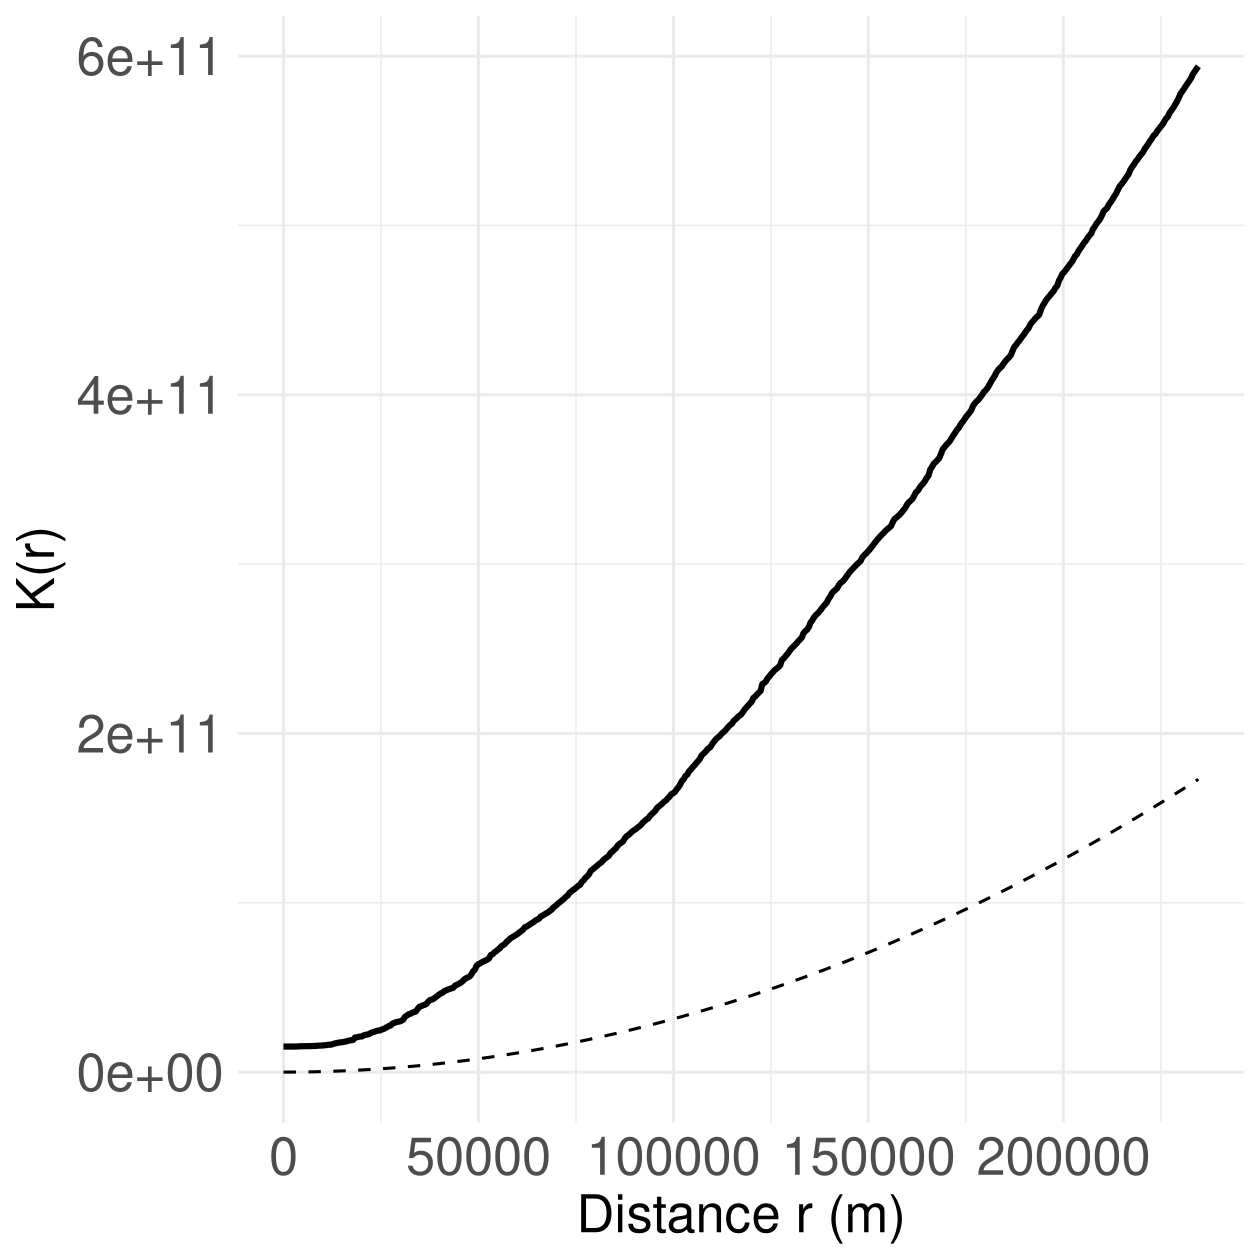

In [11]:
options(repr.plot.width = 6, repr.plot.height = 6)

ggplot(df, aes(x = r)) +
  geom_line(aes(y = K_iso), linewidth = 1) +
  geom_line(aes(y = K_theo), linetype = "dashed") +
  labs(y = "K(r)", x = "Distance r (m)") +
  theme_minimal() +
  theme(
    axis.text = element_text(size = 18),     # increase axis tick labels
    axis.title = element_text(size = 18)     # increase axis titles
  )
ggsave(paste0(output_dir, "FigureS5A_RipleyK.png"))

#### Fit LGCP model from our study

In [12]:
fit_spatial <- fit_lgcp(
  locs = locs,
  sf = colombia,
  smesh = smesh,
  covariates = covariate_matrix,
  parameters = list(
    beta = c(0, 0),
    log_tau = log(1),
    log_kappa = log(1)
  )
)

coefs_01 <- get_coefs(fit_spatial)

#### Useful functions

In [13]:
# Converts a vector of spatial field values into a grid image
field_to_im <- function(x, smesh, sf, dims = c(500,500)){
    nx <- dims[1]
    ny <- dims[2]
    xs <- seq(min(smesh$loc[, 1]), max(smesh$loc[, 1]), length = nx)
    ys <- seq(min(smesh$loc[, 2]), max(smesh$loc[, 2]), length = ny)
    data <- expand.grid(xs = xs, ys = ys)
    pxl <- sf::st_multipoint(as.matrix(data))
    A <- fmesher::fm_basis(smesh, pxl)
    data$colz <- as.vector(A %*% x)
    xy <- sf::st_as_sf(data, coords = c("xs", "ys"))
    sf::st_crs(xy) <- sf::st_crs(sf)
    idx <- lengths(sf::st_intersects(xy, sf)) > 0
    data[!idx, ] <- 0
    z_grid <- matrix(data$colz, nrow = ny, ncol = nx, byrow = TRUE)
    im_obj <- im(z_grid, xcol = xs, yrow = ys)
    return(im_obj)
}

# Computes the spatial intensity for a log-Gaussian Cox process model using a fitted TMB object and covariates
get_lambda <- function(obj, covariates){
    designmat <- cbind(1, covariates)
    res <- TMB::sdreport(obj)
    field <- res$par.random
    beta <- res$value["beta" == names(res$value)]
    beta <- as.matrix(beta, ncol = 1)
    lambda <- exp(field + designmat%*%beta)
    return(lambda)
}

#### Computes model-predicted spatial intensity over Colombia and converts into grid image

In [14]:
image <- field_to_im(x = get_lambda(fit_spatial, covariate_matrix), smesh = smesh, sf = colombia)

#### Simulate 1000 realisations from the fitted intensity (including field)

In [15]:
pp_sims <- spatstat.random::rpoispp(image, nsim = 1000)

#### Plot observed vs simulated events distribution

png 
  3

agg_record_717661450 
                   2

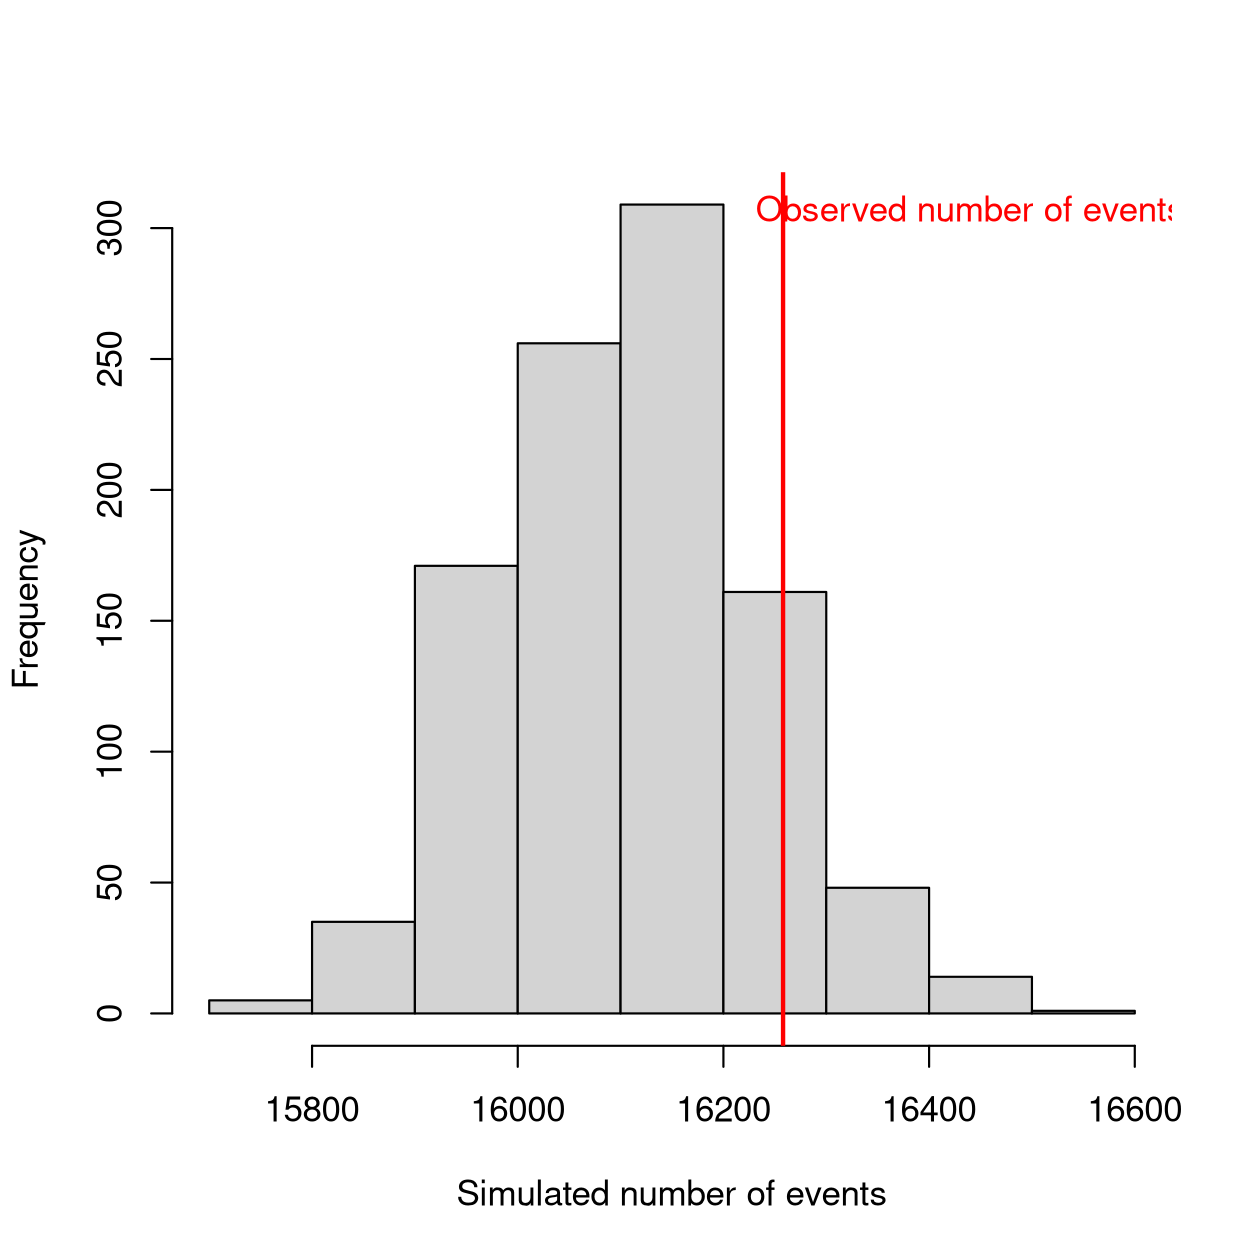

In [16]:
hist(
  lapply(pp_sims, function(x) x$n) |> unlist(),
  main = "",
  xlab = "Simulated number of events"
)
abline(v = nrow(locs), col = "red", lwd = 2)
legend("topright", bty = "n", legend = "Observed number of events", text.col = "red")

dev.copy(png, paste0(output_dir, "FigureS5B_LGCPClust_obs_sim.png"), width = 1000, height = 1000, res = 150)
dev.off()

#### Posterior predictive checking of spatial intensity using kernel density estimates with 95% intervals

In [17]:
pp_obs <- as.ppp(st_coordinates(points),
                 W = as.owin(image))

sigma_val <- 0.2

dens_obs <- density(pp_obs,
                    sigma = sigma_val,
                    dimx = 500)

dens_sims <- lapply(pp_sims,
                    density,
                    sigma = sigma_val,
                    dimx = 500)

sim_array <- simplify2array(lapply(dens_sims,
                                   function(x) x$v))

mean_sim <- apply(sim_array, c(1,2),
                  mean)

lo_sim   <- apply(sim_array, c(1,2),
                  quantile,
                  probs = 0.025)

hi_sim   <- apply(sim_array, c(1,2),
                  quantile,
                  probs = 0.975)

mean_im <- dens_obs
mean_im$v <- mean_sim

lo_im <- dens_obs
lo_im$v <- lo_sim

hi_im <- dens_obs
hi_im$v <- hi_sim

Warning message:
“1 point was rejected as lying outside the specified window”
Warning message:
“data contain duplicated points”


#### Plot observed vs simulated spatial intensity with 95% intervals

Warning message in plot.sf(colombia, add = TRUE, col = NA, lwd = 2):
“ignoring all but the first attribute”
Warning message in plot.sf(colombia, add = TRUE, col = NA, lwd = 2):
“ignoring all but the first attribute”
Warning message in plot.sf(colombia, add = TRUE, col = NA, lwd = 2):
“ignoring all but the first attribute”
Warning message in plot.sf(colombia, add = TRUE, col = NA, lwd = 2):
“ignoring all but the first attribute”


png 
  3

agg_record_1186212288 
                    2

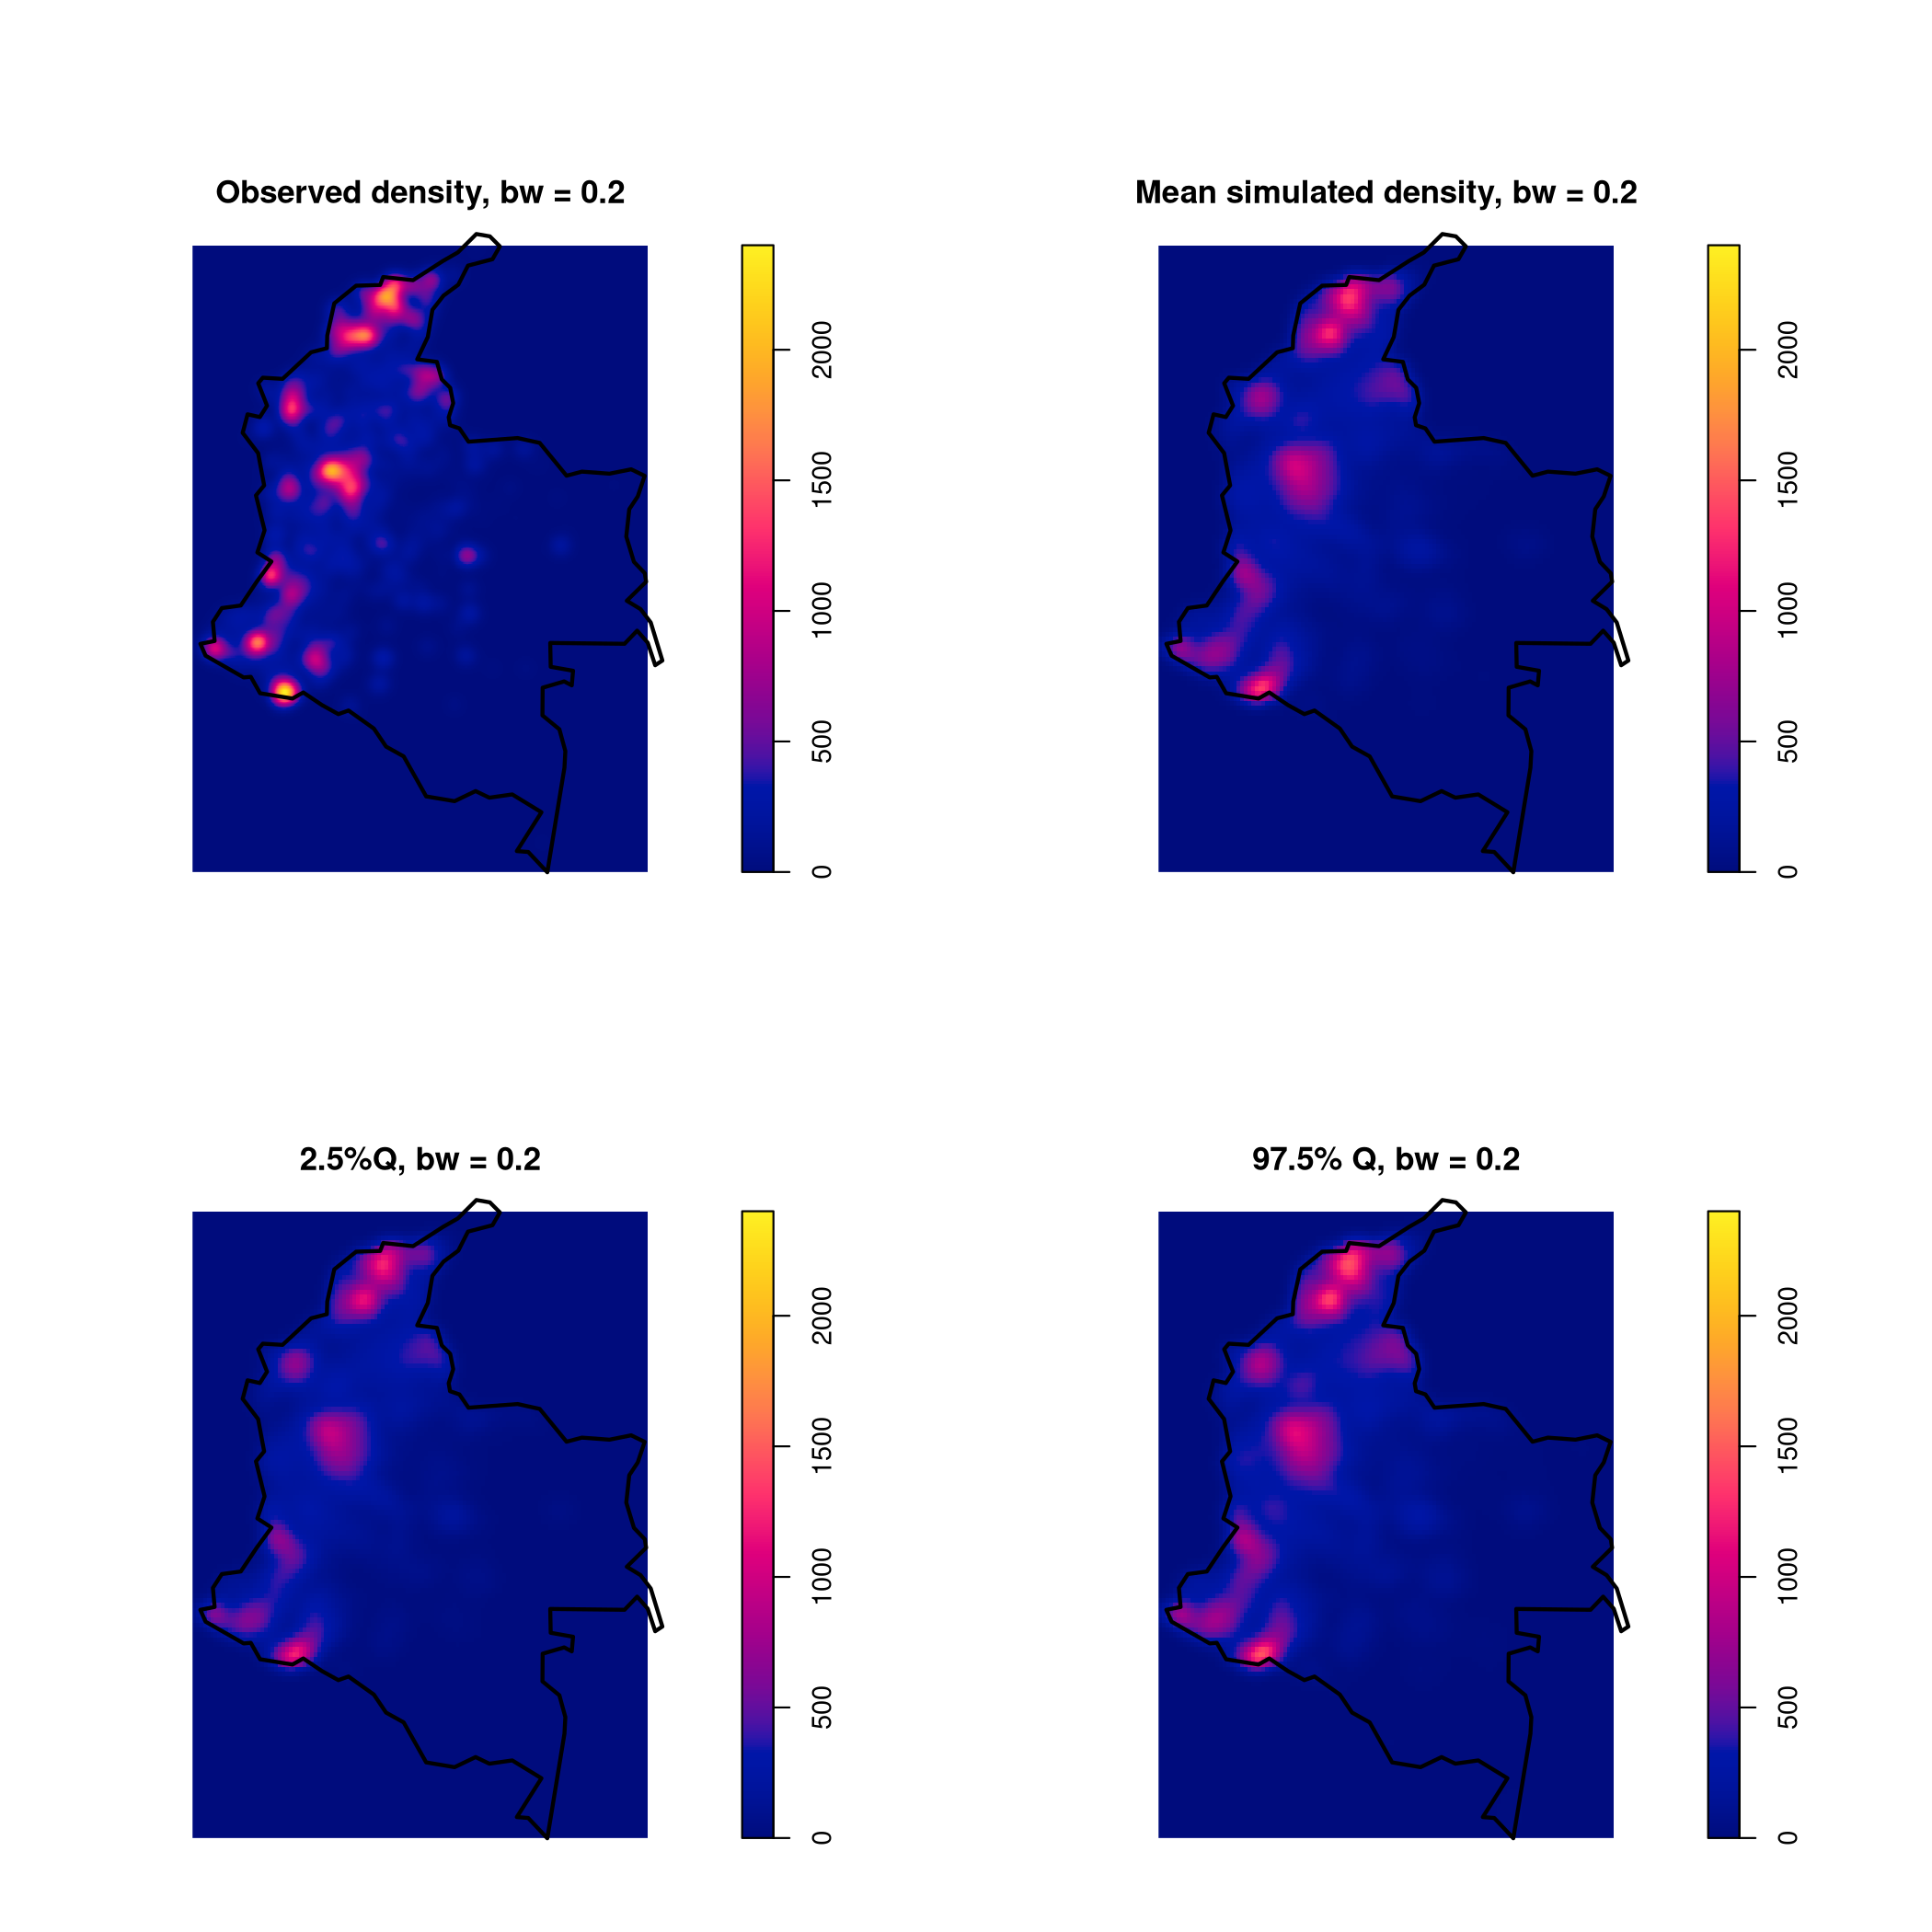

In [18]:
options(repr.plot.width = 10, repr.plot.height = 10)

par(mfrow = c(2,2), mar = c(2,2,3,2))
zlim_range <- range(c(dens_obs$v, mean_sim))

## 1
plot(dens_obs, main = "Observed density, bw = 0.2", zlim = zlim_range)
plot(colombia, add = TRUE, col = NA, lwd = 2)

## 2
plot(mean_im,  main = "Mean simulated density, bw = 0.2", zlim = zlim_range)
plot(colombia, add = TRUE, col = NA, lwd = 2)

## 3
plot(lo_im, main = "2.5%Q, bw = 0.2", zlim = zlim_range)
plot(colombia, add = TRUE, col = NA, lwd = 2)

## 4
plot(hi_im,  main = "97.5% Q, bw = 0.2", zlim = zlim_range)
plot(colombia, add = TRUE, col = NA, lwd = 2)

dev.copy(png, paste0(output_dir, "FigureS5C_LGCPIntensity_obs_sim.png"), width = 1200, height = 1200, res = 150)
dev.off()

# Hawkes process model validation

### Hawkes process model with constant baseline

In [19]:
## Times must be unique and in ascending order
SV_times <- SV_combined_data_sf_entire_conflict %>%
  mutate(time = difftime(Date, min(Date), units = "days")) %>% # Calculates the number of days since the earliest event in the dataset
  mutate(time = time + runif(nrow(SV_combined_data_sf_entire_conflict), 0, 1)) %>% # Adds random jitter (up to 1 day) to each time value - avoiding identical timestamps 
  mutate(time = time - min(time)) %>% # Re-normalizes the time so that it starts at 0
  sf::st_drop_geometry() %>%  # Drop geometry if it's an sf object
  pull(time) %>%              # Pull 'time' as a vector
  as.numeric() %>%            # Convert to numeric
  sort()                      # Sort in ascending order

#### Calculate Hawkes process model

In [20]:
## Using stelfi library for fitting Hawkes and log-Gaussian Cox point process models
## parameter starting values
SV_params <- c(mu = 9, alpha = 0.3, beta = 1)

## fit model
fit_hawkes_const <- fit_hawkes(times = SV_times, parameters = SV_params)

# Store parameters
hawkes_model_coefs <- get_coefs(fit_hawkes_const)

#### Show model parameters

In [21]:
print("Hawkes model parameters fitted with constant baseline")
print(round(hawkes_model_coefs, 3))

[1] "Hawkes model parameters fitted with constant baseline"
      Estimate Std. Error
mu       0.009      0.001
alpha    0.186      0.011
beta     0.188      0.011


#### Plot fitted Hawkes process model

Warning message in scale_x_date(limits = c(as.Date("1965-01-01"), as.Date("2025-12-31")), :
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”
Warning message:
“Removed 26 rows containing missing values or values outside the scale range
(`geom_line()`).”


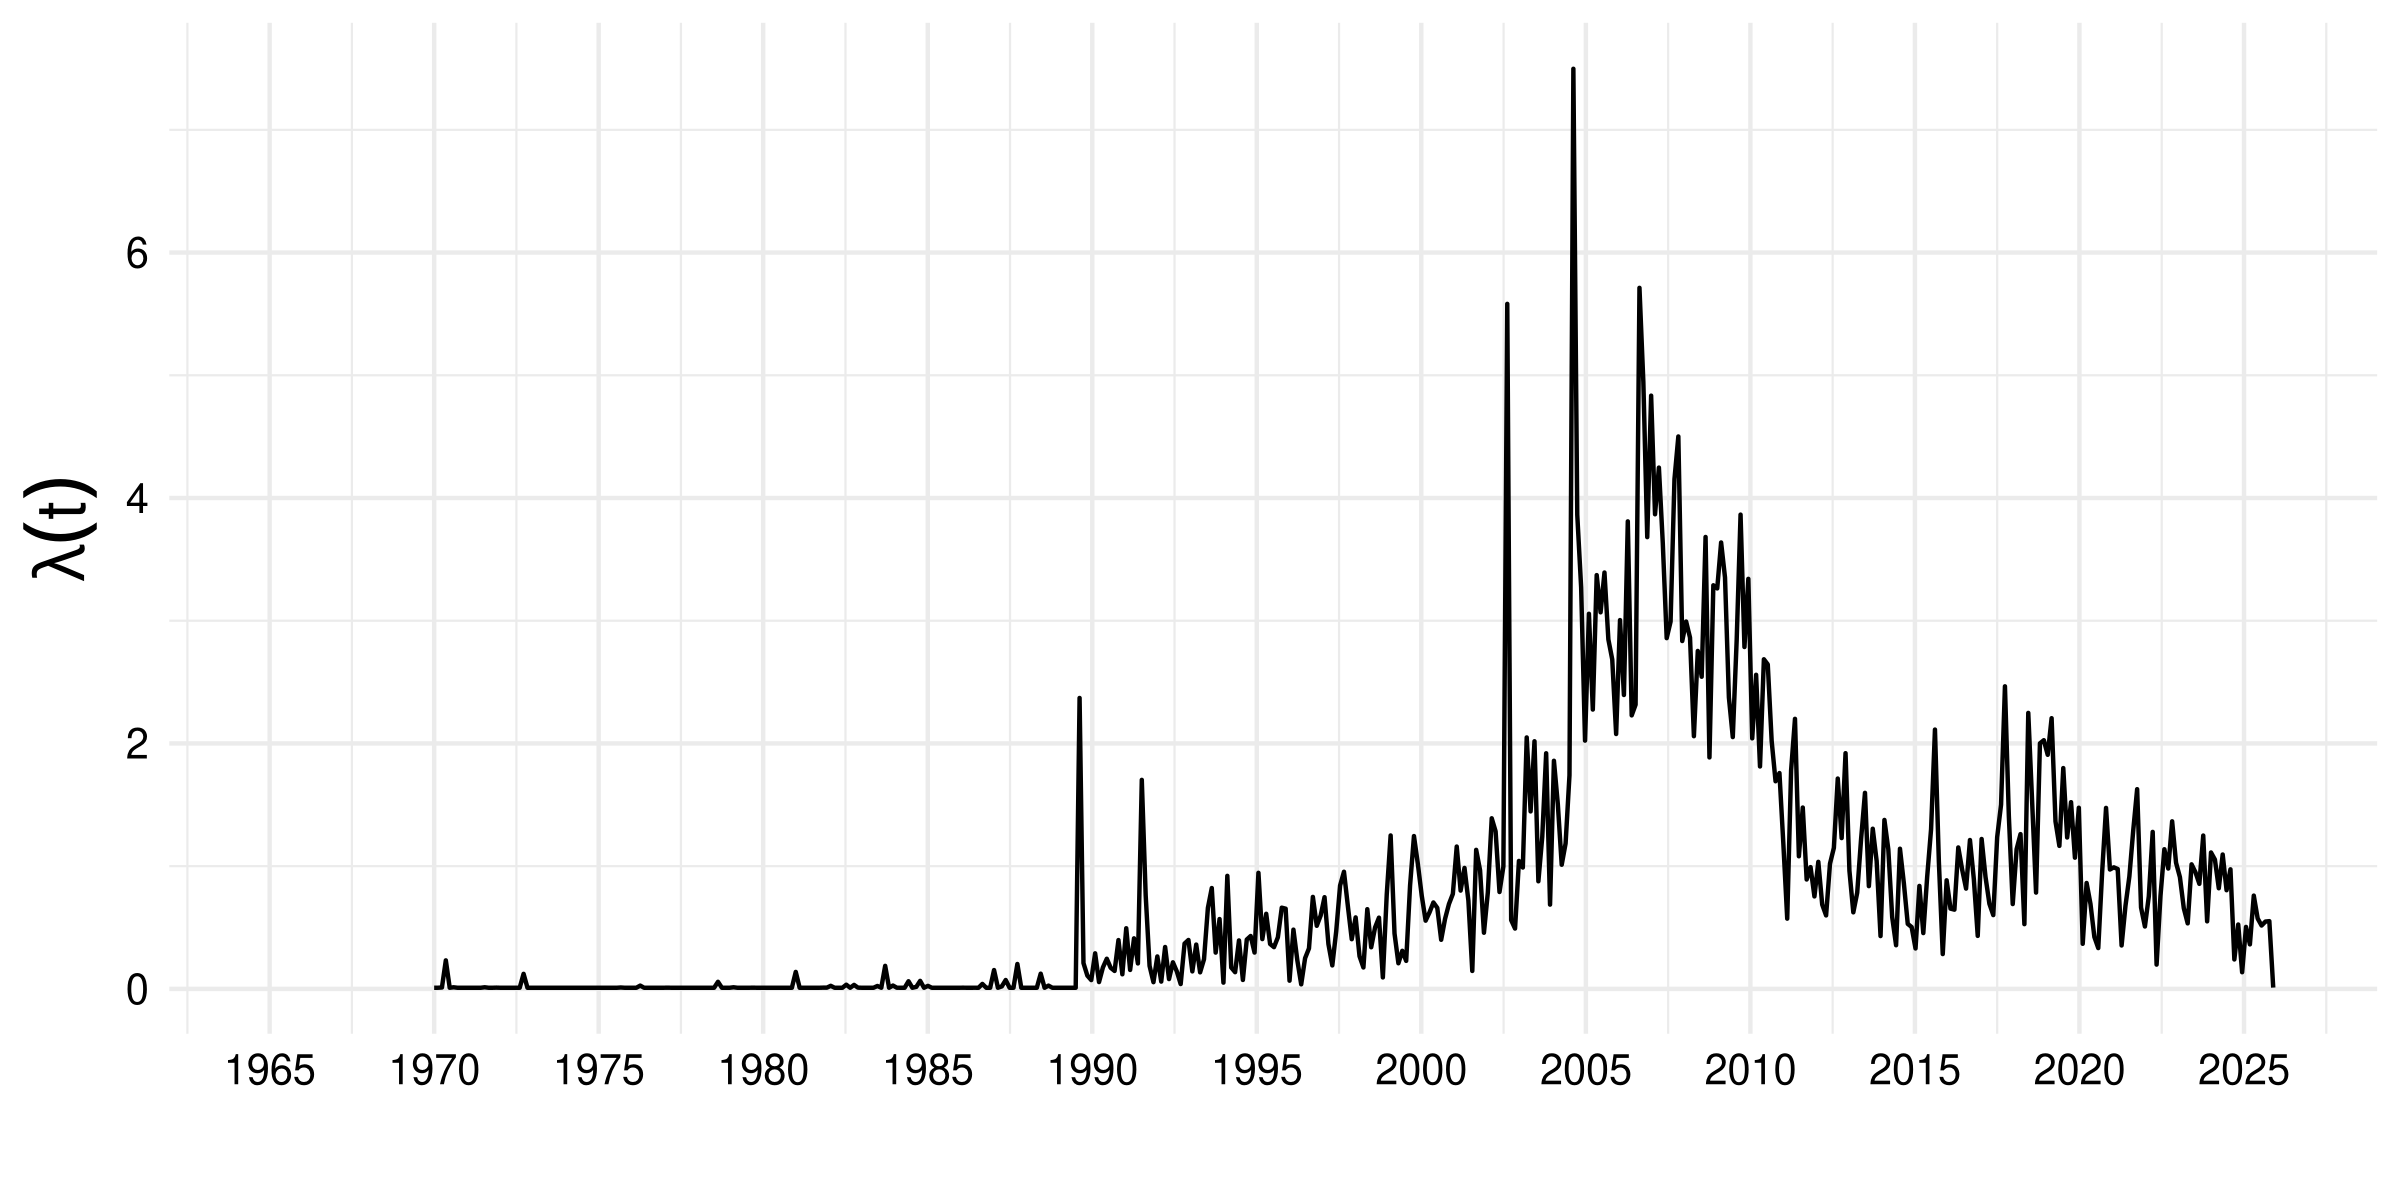

In [22]:
# Set image size
options(repr.plot.width=8, repr.plot.height=4, repr.plot.res = 300)

show_hawkes(fit_hawkes_const) + 
  theme(text = element_text(size = 14, color = "black"),
        axis.title = element_text(size = 16, color = "black"),
        axis.text = element_text(size = 10, color = "black"),
        plot.title = element_text(size = 18, color = "black"),
        legend.text = element_text(size = 12, color = "black"),
        legend.title = element_text(size = 14, color = "black")) +
  scale_x_date(
    limits = c(as.Date("1965-01-01"), as.Date("2025-12-31")),
    breaks = seq(as.Date("1960-01-01"), as.Date("2030-01-01"), by = "5 years"),
    date_labels = "%Y"
  )

#### Monte Carlo posterior predictive check: mean inter-event time (constant baseline)

In [23]:
# Monte Carlo posterior predictive check: constant baseline Hawkes model
# Simulate 1000 realisations from the fitted model, compare mean inter-event
# waiting time against the observed value.

observed_mean_wait <- mean(diff(SV_times))
T_max <- max(SV_times)

mu_hat  <- hawkes_model_coefs["mu",    "Estimate"]
alpha_hat <- hawkes_model_coefs["alpha", "Estimate"]
beta_hat  <- hawkes_model_coefs["beta",  "Estimate"]

n_sims <- 1000
sim_mean_waits <- numeric(n_sims)

for (i in seq_len(n_sims)) {
  sim_times <- hawkes::simulateHawkes(
    lambda0 = mu_hat, alpha = alpha_hat, beta = beta_hat, horizon = T_max
  )[[1]]

  if (length(sim_times) > 1) {
    sim_mean_waits[i] <- mean(diff(sim_times))
  } else {
    sim_mean_waits[i] <- NA
  }

  if (i %% 200 == 0) cat(sprintf("Simulation %d/%d\n", i, n_sims))
}

cat(sprintf("\nObserved mean inter-event time: %.2f days\n", observed_mean_wait))
cat(sprintf("Simulated median: %.2f days\n", median(sim_mean_waits, na.rm = TRUE)))
cat(sprintf("Simulated 95%% interval: [%.2f, %.2f]\n",
            quantile(sim_mean_waits, 0.025, na.rm = TRUE),
            quantile(sim_mean_waits, 0.975, na.rm = TRUE)))

Simulation 200/1000
Simulation 400/1000
Simulation 600/1000
Simulation 800/1000
Simulation 1000/1000

Observed mean inter-event time: 1.32 days
Simulated median: 1.64 days
Simulated 95% interval: [0.53, 5.16]


Generate plot of posterior predictive check of fitted Hawkes process models: observed versus simulated mean inter-event time

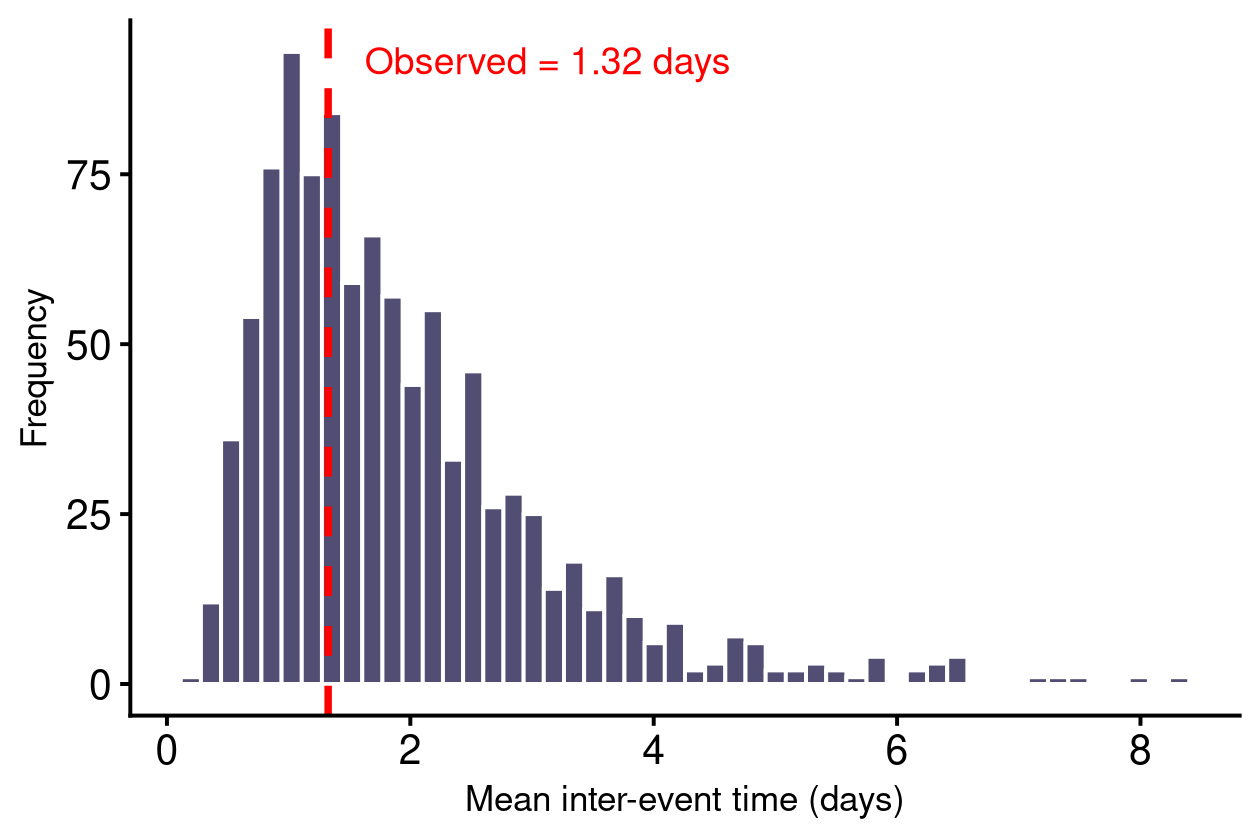

In [24]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 210)

ggplot(data.frame(x = sim_mean_waits), aes(x = x)) +
  geom_histogram(bins = 50, fill = "#080035", alpha = 0.7, color = "white") +
  geom_vline(xintercept = observed_mean_wait, color = "red",
             linewidth = 1.2, linetype = "dashed") +
  annotate("text", x = observed_mean_wait, y = Inf,
           label = sprintf("Observed = %.2f days", observed_mean_wait),
           hjust = -0.1, vjust = 2, color = "red", size = 4.5) +
  labs(x = "Mean inter-event time (days)",
       y = "Frequency") +
  theme_classic(base_size = 14) +
  theme(axis.title = element_text(size = 12),
        axis.text = element_text(size = 14))

ggsave(paste0(output_dir, "FigureS8A_hawkes_ppc_constant_entire.png"),
       width = 10, height = 6, dpi = 300)

### Hawkes process model adjusted for changing baseline of events

#### Estimate non-homogenous background rate curve by fitting splines to frequency over sexual violence events over time

In [25]:
min_time <- min(SV_times)
max_time <- max(SV_times)

# Estimate a crude baseline intensity from the data
n_bins <- 150   # Splits the time span into 150 equal-width bins
breaks <- seq(min_time, max_time, length.out = n_bins + 1) # Counts how many events fall in each bin
h <- hist(SV_times, breaks = breaks, plot = FALSE) # Divides counts by bin width

# Produces a step-like baseline intensity estimate
midpoints <- h$mids
counts    <- h$counts
dt        <- diff(breaks)[1]                  # uniform bin width
rate      <- counts / dt                      # counts -> approximate intensity

# Smooth the crude baseline with a spline
baseline_data <- data.frame(t = midpoints, y = rate)

# Fit a smooth spline to intensity 
baseline_spline <- smooth.spline(baseline_data$t, baseline_data$y, cv = TRUE) #cv = TRUE chooses the degree of smoothing automatically.
# The result is a smooth estimate of how the baseline event rate changes over time.

# Clamp helper to avoid NA predictions at the edges
.clamp <- function(x, lo, hi) pmin(pmax(x, lo), hi)

# Instantaneous baseline - Define the baseline function μ(t)
background <- function(params, t) {
  A <- exp(params[[1]])
  t_clamped <- .clamp(t, min_time, max_time)
  vals <- predict(baseline_spline, t_clamped)$y
  A * pmax(vals, 1e-8)   # enforce positivity
}

# Cumulative baseline - Define the cumulative baseline ∫ μ(u) du
background_integral <- function(params, x) {
  A <- exp(params[[1]])
  f <- function(u) {
    u_clamped <- .clamp(u, min_time, max_time)
    vals <- predict(baseline_spline, u_clamped)$y
    A * pmax(vals, 1e-8)
  }
  sapply(x, function(xi) {
    upper <- max(min(xi, max_time), min_time)
    if (upper <= min_time) return(0)
    stats::integrate(f, lower = min_time, upper = upper,
                     rel.tol = 1e-6)$value
  })
}

# Choose starting values for fitting - Setting initial guess for log(A) based on the mean baseline rate.
background_sv <- list(log(mean(baseline_data$y) + 1))

#### Fit the Hawkes process model with non-homogenous background rate as defined above

In [26]:
# Set model parameters
SV_params <- c(mu = 9, alpha = 0.3, beta = 1)

# Fit the Hawkes model
fit_inhom <- fit_hawkes_cbf(
  times                  = SV_times,
  parameters             = SV_params,
  background             = background,
  background_integral    = background_integral,
  background_parameters  = background_sv
)

Warning message in stats::optim(par = background_parameters, fn = optimize_background_one, :
“one-dimensional optimization by Nelder-Mead is unreliable:
use "Brent" or optimize() directly”


Check model fit given warning

In [27]:
  # Check if optimization improved the fit
  cat("Constant baseline model negative log-likelihood:", fit_hawkes_const$objective, "\n")
  cat("Inhomogeneous baseline model negative log-likelihood:", fit_inhom$objective, "\n")
  cat("Improvement:", fit_hawkes_const$objective - fit_inhom$objective, "\n")

Constant baseline model negative log-likelihood: 8752.203 
Inhomogeneous baseline model negative log-likelihood: 6621.953 
Improvement: 2130.25 


#### Show model parameters

In [28]:
# Hawkes coefficients
inhom_hawks_coefs <- get_coefs(fit_inhom)
print("Hawkes model parameters from model fitted with non-homogenous baseline to account for changing background rate")
print(round(inhom_hawks_coefs, 3))

[1] "Hawkes model parameters from model fitted with non-homogenous baseline to account for changing background rate"
      Estimate Std. Error
alpha    1.338      0.043
beta     4.002      0.128
BP 1    -0.407         NA


#### Show estimated baseline intensity

In [29]:
# Extract fitted results
A_hat <- exp(fit_inhom$background_parameters[1])
print(round(A_hat, 3))

[1] 0.666


#### Show negative log likelihood

In [30]:
# Objective (neg. log-likelihood)
print(round(fit_inhom$objective, 3))

[1] 6621.953


#### Plot Hawkes process model with inhomogenous baseline

Warning message in scale_x_date(limits = c(as.Date("1965-01-01"), as.Date("2025-12-31")), :
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”
Warning message:
“Removed 26 rows containing missing values or values outside the scale range
(`geom_line()`).”


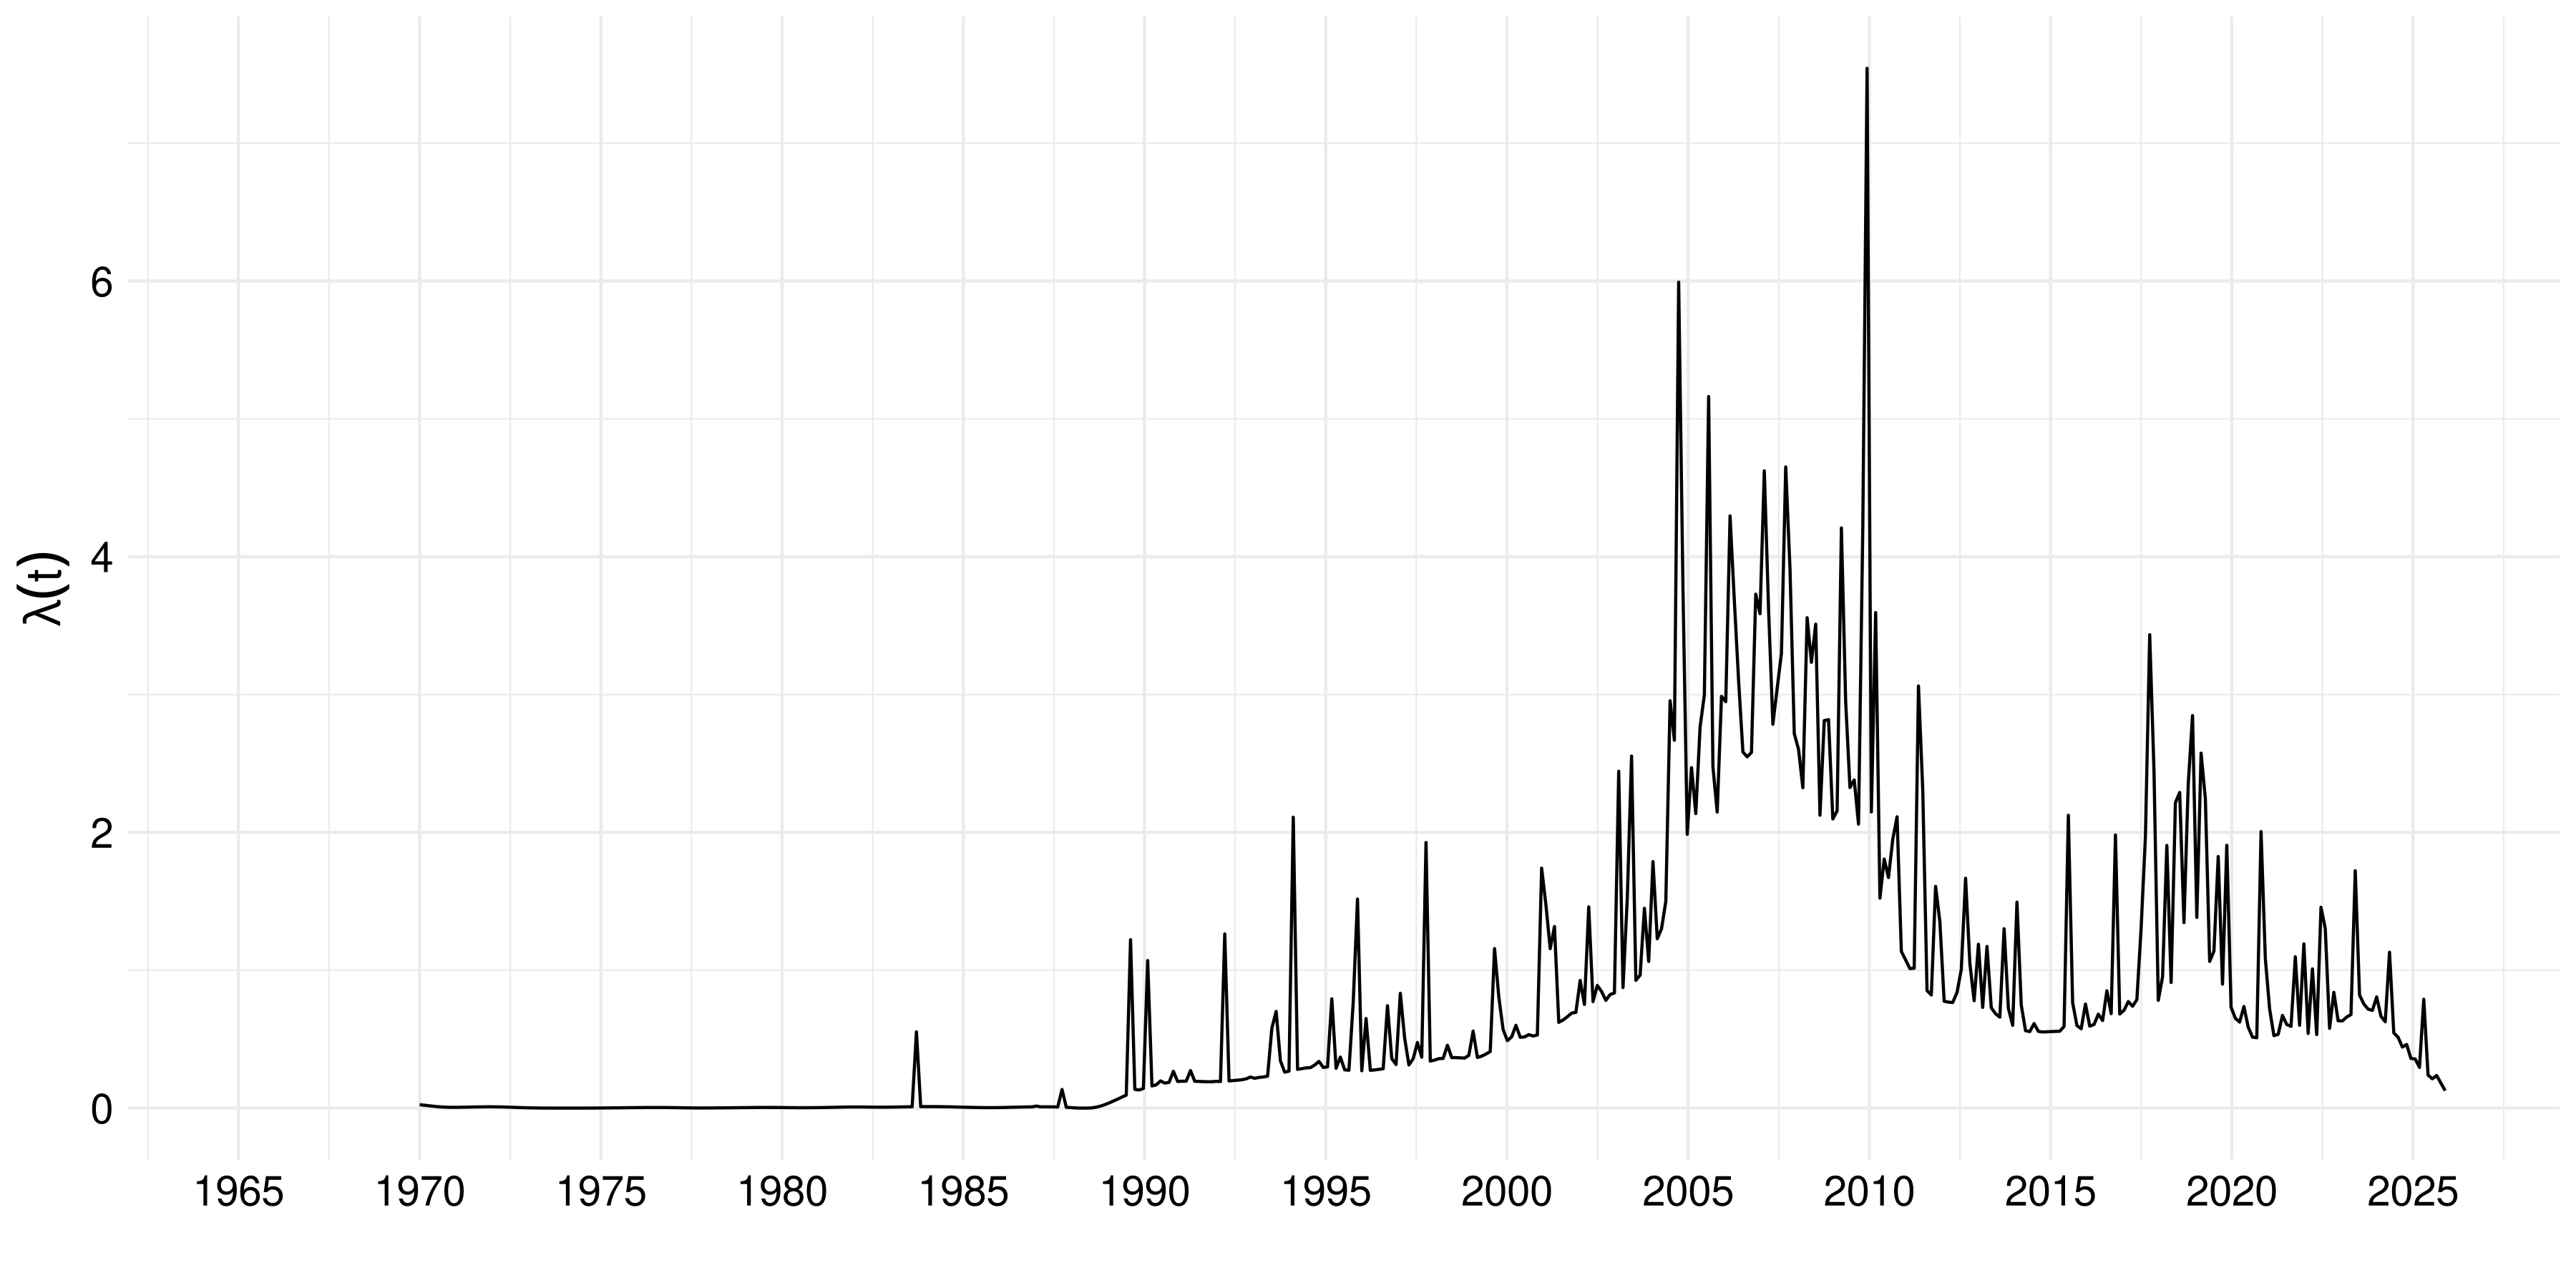

In [31]:
options(repr.plot.width=12, repr.plot.height=6, repr.plot.res = 300)

# Plot fitted baseline vs events
show_hawkes(fit_inhom) +
  theme(text = element_text(size = 14, color = "black"),
        axis.title = element_text(size = 16, color = "black"),
        axis.text = element_text(size = 14, color = "black"),
        plot.title = element_text(size = 18, color = "black"),
        legend.text = element_text(size = 12, color = "black"),
        legend.title = element_text(size = 14, color = "black")) +
  scale_x_date(
    limits = c(as.Date("1965-01-01"), as.Date("2025-12-31")),
    breaks = seq(as.Date("1960-01-01"), as.Date("2030-01-01"), by = "5 years"),
    date_labels = "%Y"
  )

#### Monte Carlo posterior predictive check: mean inter-event time (inhomogeneous baseline)

In [32]:
# Monte Carlo posterior predictive check: inhomogeneous baseline Hawkes model
# Uses Ogata's thinning algorithm with the fitted spline background and an
# efficient running trigger sum to avoid O(n) per candidate evaluation.

observed_mean_wait <- mean(diff(SV_times))
T_max <- max(SV_times)

# Extract fitted parameters
alpha_hat_inhom <- inhom_hawks_coefs["alpha", "Estimate"]
beta_hat_inhom  <- inhom_hawks_coefs["beta",  "Estimate"]
bg_params       <- fit_inhom$background_parameters

# Ogata's thinning algorithm for Hawkes with inhomogeneous background
sim_hawkes_inhom <- function(bg_fn, bg_params, alpha, beta, T_max) {
  times <- c()
  t <- 0
  S <- 0  # running trigger sum: sum of exp(-beta*(t - t_i))

  # Precompute background upper bound
  t_grid <- seq(0, T_max, length.out = 5000)
  bg_max <- max(sapply(t_grid, function(tt) bg_fn(bg_params, tt)))

  while (t < T_max) {
    M <- bg_max + alpha * S
    if (M < 1e-10) M <- 1e-10

    dt <- rexp(1, rate = M)
    t  <- t + dt
    if (t > T_max) break

    # Decay running sum to new time
    S <- S * exp(-beta * dt)

    # Actual conditional intensity
    lambda_t <- bg_fn(bg_params, t) + alpha * S

    # Accept / reject
    if (runif(1) < lambda_t / M) {
      times <- c(times, t)
      S <- S + 1
    }
  }

  return(times)
}

n_sims <- 1000
sim_mean_waits_inhom <- numeric(n_sims)

for (i in seq_len(n_sims)) {
  sim_times <- sim_hawkes_inhom(
    bg_fn = background, bg_params = bg_params,
    alpha = alpha_hat_inhom, beta = beta_hat_inhom, T_max = T_max
  )

  if (length(sim_times) > 1) {
    sim_mean_waits_inhom[i] <- mean(diff(sim_times))
  } else {
    sim_mean_waits_inhom[i] <- NA
  }

  if (i %% 100 == 0) cat(sprintf("Simulation %d/%d\n", i, n_sims))
}

cat(sprintf("\nObserved mean inter-event time: %.2f days\n", observed_mean_wait))
cat(sprintf("Simulated median: %.2f days\n", median(sim_mean_waits_inhom, na.rm = TRUE)))
cat(sprintf("Simulated 95%% interval: [%.2f, %.2f]\n",
            quantile(sim_mean_waits_inhom, 0.025, na.rm = TRUE),
            quantile(sim_mean_waits_inhom, 0.975, na.rm = TRUE)))

Simulation 100/1000
Simulation 200/1000
Simulation 300/1000
Simulation 400/1000
Simulation 500/1000
Simulation 600/1000
Simulation 700/1000
Simulation 800/1000
Simulation 900/1000
Simulation 1000/1000

Observed mean inter-event time: 1.32 days
Simulated median: 1.31 days
Simulated 95% interval: [1.26, 1.34]


Generate plot of posterior predictive check of fitted Hawkes process models: observed versus simulated mean inter-event time

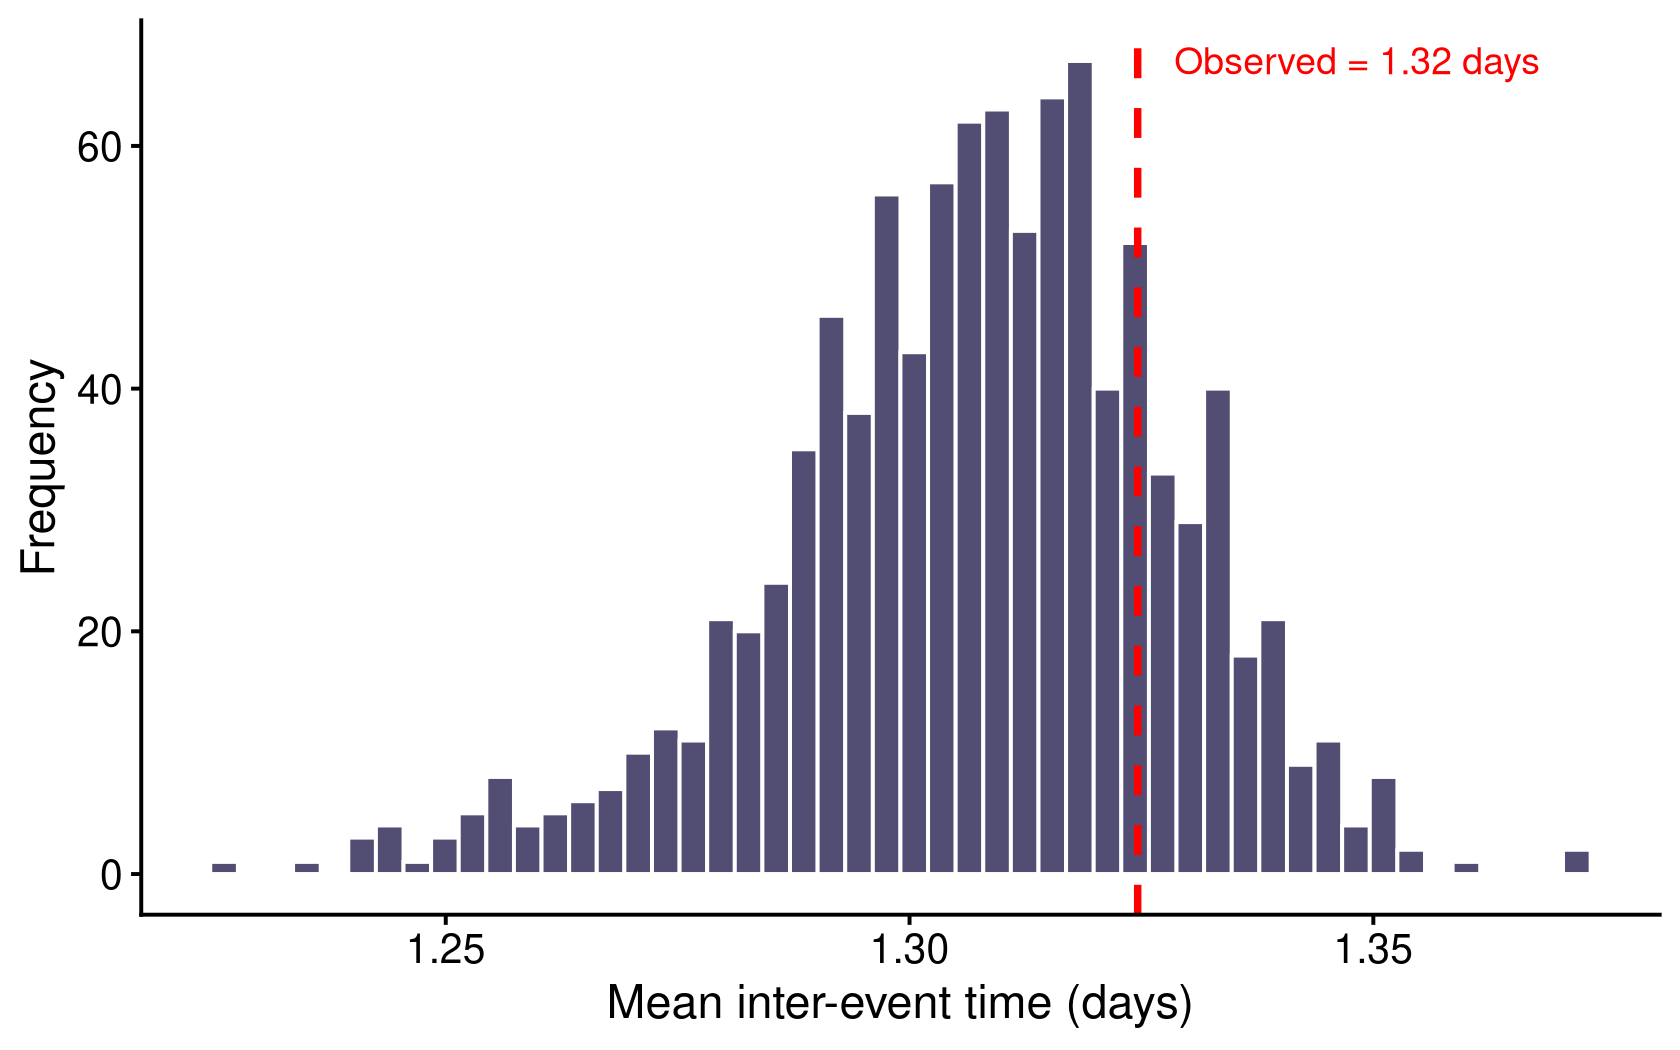

In [34]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 210)

ggplot(data.frame(x = sim_mean_waits_inhom), aes(x = x)) +
  geom_histogram(bins = 50, fill = "#080035", alpha = 0.7, color = "white") +
  geom_vline(xintercept = observed_mean_wait, color = "red",
             linewidth = 1.2, linetype = "dashed") +
  annotate("text", x = observed_mean_wait, y = Inf,
           label = sprintf("Observed = %.2f days", observed_mean_wait),
           hjust = -0.1, vjust = 2, color = "red", size = 4.5) +
  labs(x = "Mean inter-event time (days)",
       y = "Frequency") +
  theme_classic(base_size = 14) +
  theme(axis.title = element_text(size = 16),
        axis.text = element_text(size = 14))

ggsave(paste0(output_dir, "FigureS8B_hawkes_ppc_inhom_entire.png"),
       width = 10, height = 6, dpi = 300)

### Show version of R and versions of packages used in this analysis

In [35]:
r_version <- R.version

# Format and print the R version details
cat(paste("R version:", r_version$version.string), "\n")
cat(paste("Platform:", r_version$platform), "\n")

R version: R version 4.5.0 (2025-04-11) 
Platform: x86_64-pc-linux-gnu 


In [36]:
loaded_packages <- c("dplyr", "janitor", 
                     "readxl", 
                     "ggplot2", "patchwork", 
                     "sf", "rnaturalearth", "rnaturalearthdata", 
                     "spatstat.geom", "spatstat.linnet", "spatstat.explore", "terra",
                     "hawkes", "stelfi", 
                     "inlabru", "INLA",
                     "future.apply")
                     
# Print package names and versions for the specified packages
for (pkg in loaded_packages) {
    version <- packageVersion(pkg)
    cat(paste(pkg, " version: ", version, sep = ""), "\n")
}

dplyr version: 1.1.4 
janitor version: 2.2.1 
readxl version: 1.4.5 
ggplot2 version: 4.0.0 
patchwork version: 1.3.2 
sf version: 1.0.21 
rnaturalearth version: 1.1.0 
rnaturalearthdata version: 1.0.0 
spatstat.geom version: 3.6.0 
spatstat.linnet version: 3.3.2 
spatstat.explore version: 3.5.3 
terra version: 1.8.70 
hawkes version: 0.0.4 
stelfi version: 1.0.2 
inlabru version: 2.13.0 
INLA version: 25.6.7 
future.apply version: 1.20.1 
